## EDA

##### 1. Understanding the selling price

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def format_lakh(x, pos):
    return f"₹{x/100000:.0f}L"

df = pd.read_csv("../data/processed/used_car_dataset_cleaned.csv")

sns.set_theme(style="darkgrid")

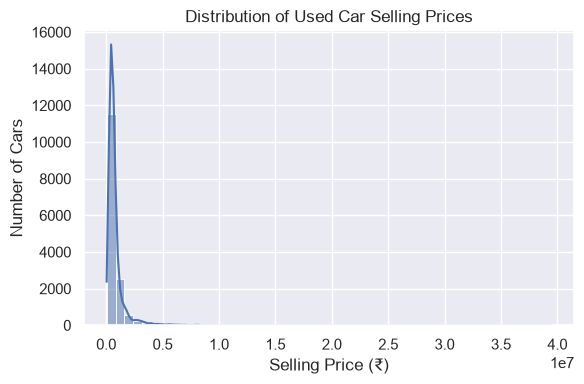

In [4]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x="selling_price",
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../images/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
df["log_selling_price"] = np.log1p(df["selling_price"])

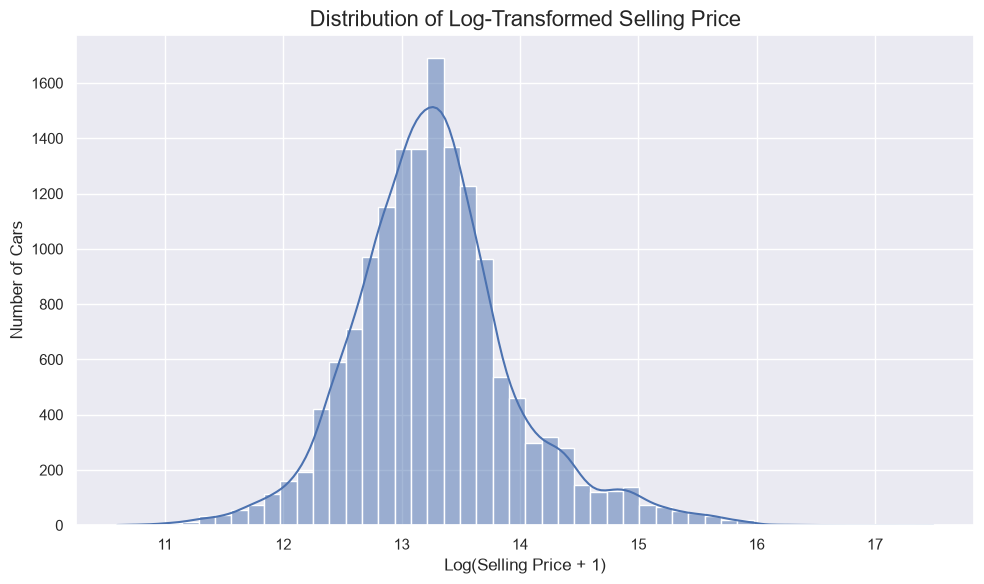

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="log_selling_price",
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Selling Price", fontsize=16)
plt.xlabel("Log(Selling Price + 1)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../images/log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
print("Original price skewness:", df["selling_price"].skew())

Original price skewness: 10.10889556800239


In [8]:
print("Log price skewness:", df["log_selling_price"].skew())

Log price skewness: 0.5641599769267792


##### 2. Price vs Vehicle Age

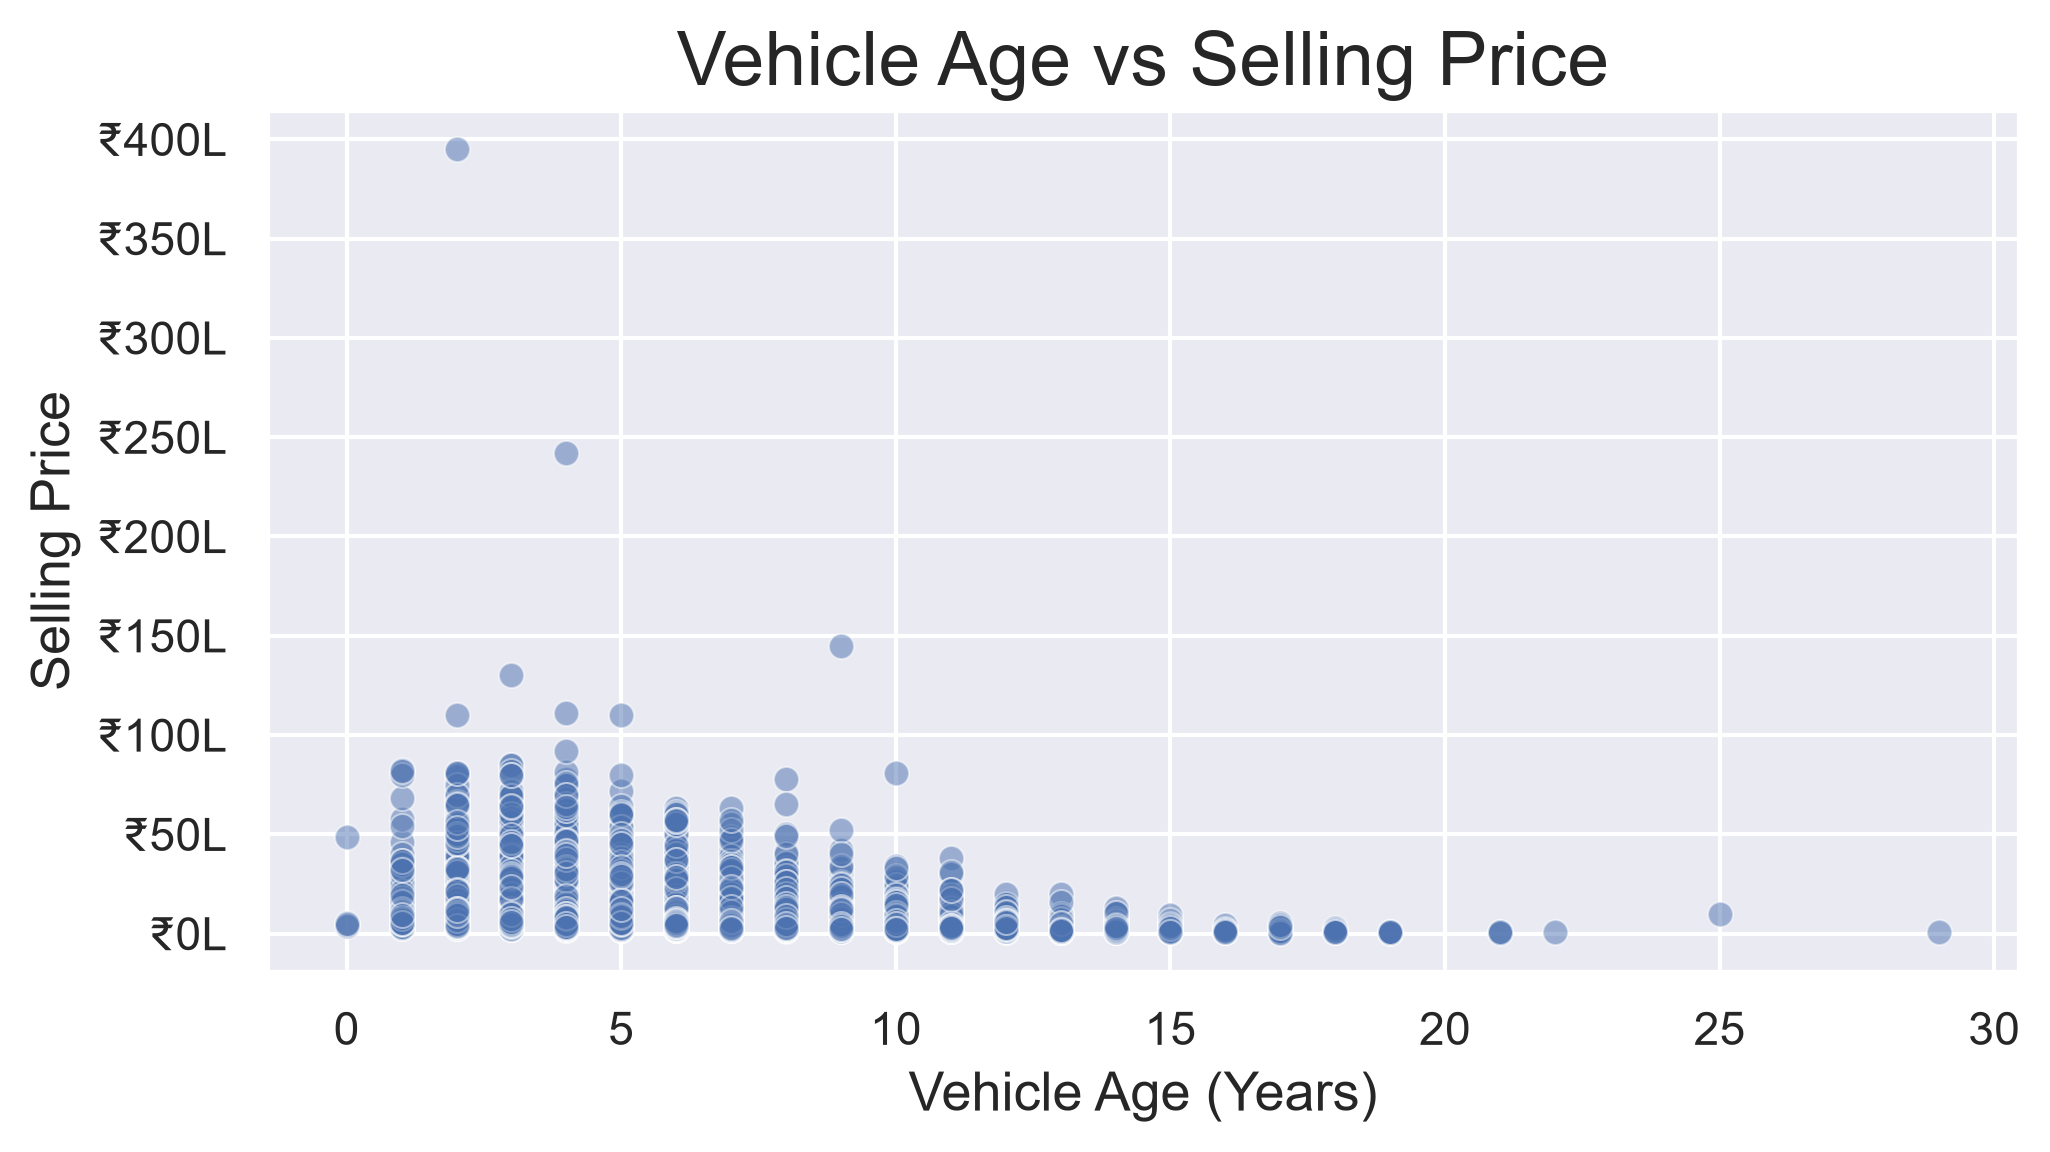

In [9]:
#using scatter plt because both variables are numerical

plt.figure(figsize=(7,4), dpi=300)

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price",
    alpha=0.5
)

plt.title("Vehicle Age vs Selling Price", fontsize=18)
plt.xlabel("Vehicle Age (Years)", fontsize=13)
plt.ylabel("Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/price_vs_vehicle_age.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#selling prices go as high as ₹39,500,000. 1e7 means 10,000,000.

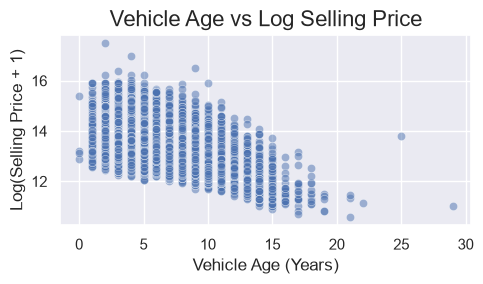

In [10]:
#second version using the log price

plt.figure(figsize=(5,3))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="log_selling_price",
    alpha=0.5
)

plt.title("Vehicle Age vs Log Selling Price", fontsize=16)
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Log(Selling Price + 1)")

plt.tight_layout()

plt.savefig(
    "../images/age_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 3. Km_driven vs Selling Price

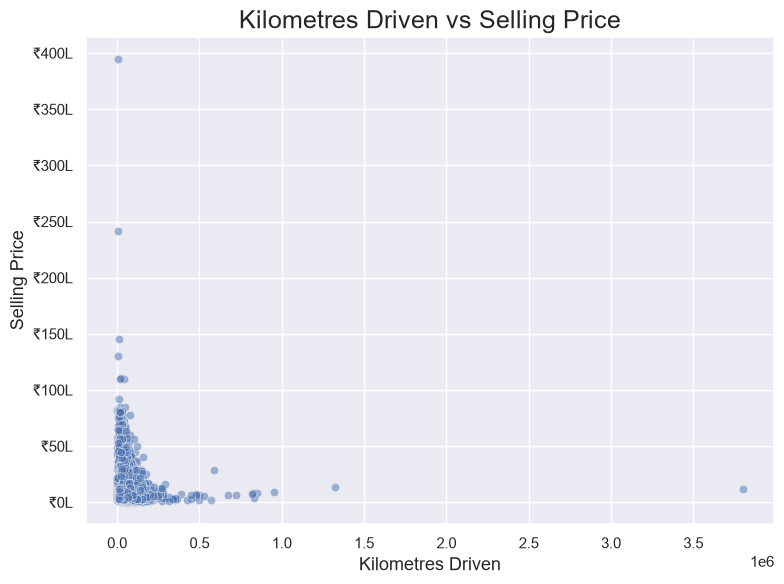

In [11]:
#Does a car's selling price generally decrease as the kilometres driven increase?
#using scatter plt because both variables are numerical

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price",
    alpha=0.5
)

plt.title("Kilometres Driven vs Selling Price", fontsize=18)
plt.xlabel("Kilometres Driven", fontsize=13)
plt.ylabel("Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/km_driven_vs_price.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

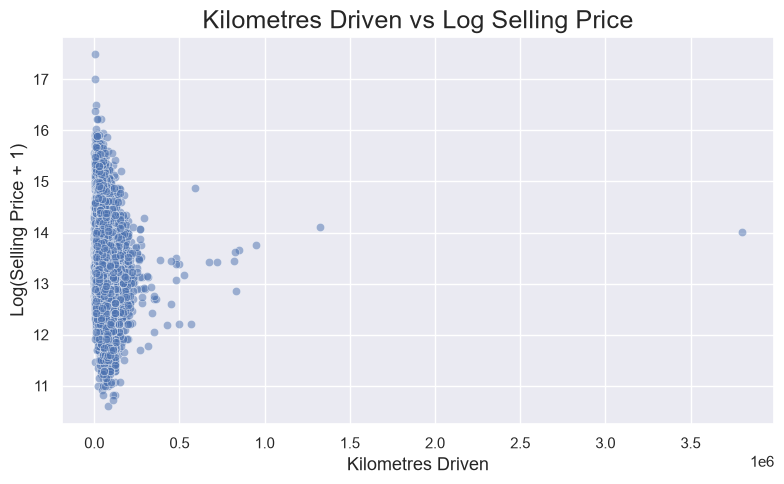

In [12]:
#Log price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="log_selling_price",
    alpha=0.5
)

plt.title("Kilometres Driven vs Log Selling Price", fontsize=18)
plt.xlabel("Kilometres Driven", fontsize=13)
plt.ylabel("Log(Selling Price + 1)", fontsize=13)

plt.tight_layout()

plt.savefig(
    "../images/km_driven_vs_log_price.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [13]:
#calculating the correlation between km_driven and selling_price
df[["km_driven", "selling_price"]].corr()

,km_driven,selling_price
km_driven,1.000000,-0.079548
selling_price,-0.079548,1.000000


In [14]:
df[["km_driven", "log_selling_price"]].corr()

,km_driven,log_selling_price
km_driven,1.000000,-0.094871
log_selling_price,-0.094871,1.000000


#### 4. Vehicle Age vs Price

In [15]:
#using median instead of mean bcz the data is skewed and median is more robust to outliers.
age_price = (
    df.groupby("vehicle_age")["selling_price"]
    .median()
    .reset_index()
)

age_price

,vehicle_age,selling_price
0,0,525000.0
1,1,750000.0
2,2,820000.0
3,3,748000.0
4,4,695500.0
5,5,600000.0
6,6,550000.0
7,7,500000.0
8,8,450000.0
9,9,400000.0


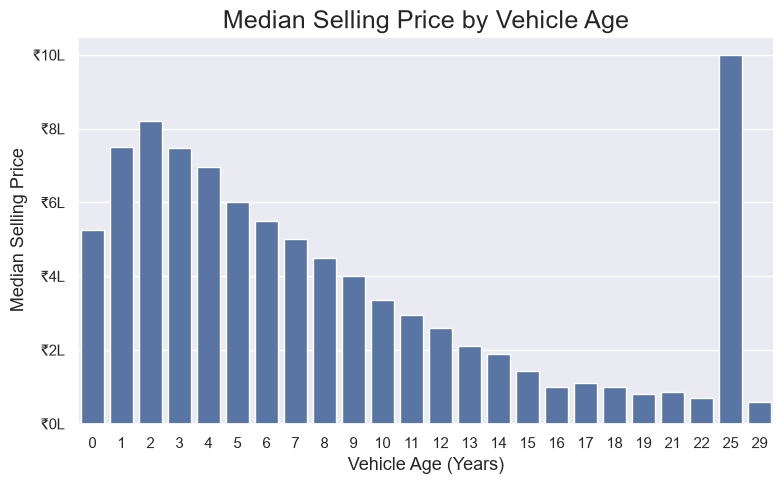

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=age_price,
    x="vehicle_age",
    y="selling_price"
)

plt.title("Median Selling Price by Vehicle Age", fontsize=18)
plt.xlabel("Vehicle Age (Years)", fontsize=13)
plt.ylabel("Median Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_vehicle_age.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [17]:
df.groupby("vehicle_age")["selling_price"].agg(
    ["count", "mean", "median"]
)

#As vehicle age increases, the typical selling price decreases.

,count,mean,median
vehicle_age,,,
0,4,1.575000e+06,525000.0
1,221,1.096977e+06,750000.0
2,1135,1.144514e+06,820000.0
3,1896,9.773270e+05,748000.0
4,2220,9.490419e+05,695500.0
5,2094,8.202058e+05,600000.0
6,1904,7.281607e+05,550000.0
7,1427,7.000722e+05,500000.0
8,1271,6.275114e+05,450000.0


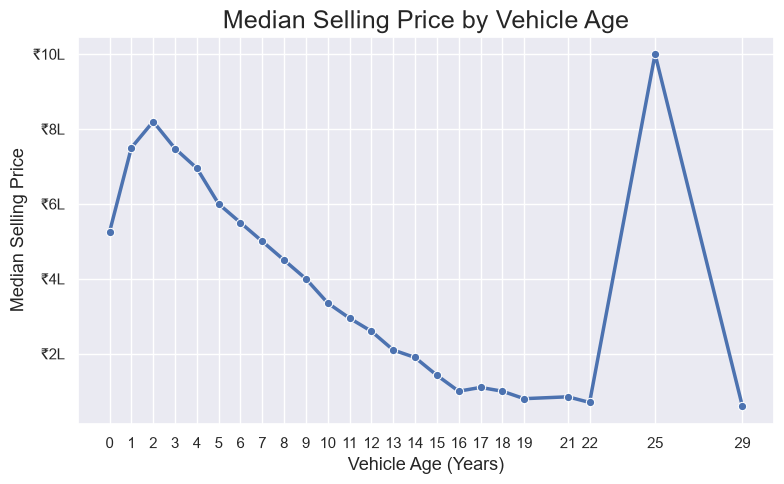

In [18]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=age_price,
    x="vehicle_age",
    y="selling_price",
    marker="o",
    linewidth=2.5
)

plt.title("Median Selling Price by Vehicle Age", fontsize=18)
plt.xlabel("Vehicle Age (Years)", fontsize=13)
plt.ylabel("Median Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.xticks(age_price["vehicle_age"])

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_vehicle_age.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

##### Vehicle age shows a clear negative relationship with used-car prices. The median selling price generally declines as vehicles become older, indicating depreciation is an important factor in used-car valuation.

#### 5. Brand Analysis

In [19]:
brand_counts = (
    df["brand"]
    .value_counts()
    .head(10)
)

brand_counts

brand
Maruti        4933
Hyundai       2952
Honda         1476
Mahindra       999
Toyota         789
Ford           776
Volkswagen     614
Renault        527
BMW            436
Tata           421
Name: count, dtype: int64

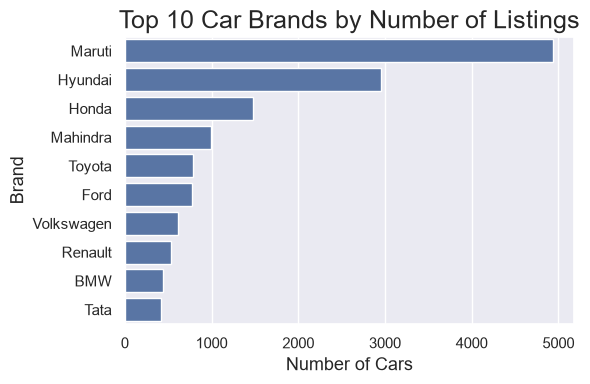

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=brand_counts.values,
    y=brand_counts.index
)

plt.title("Top 10 Car Brands by Number of Listings", fontsize=18)
plt.xlabel("Number of Cars", fontsize=13)
plt.ylabel("Brand", fontsize=13)

plt.tight_layout()

plt.savefig(
    "../images/top_10_brands_by_listings.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [21]:
top_brands = brand_counts.index

brand_price = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["selling_price"]
    .median()
    .sort_values(ascending=False)
)

brand_price

brand
BMW           2287500.0
Toyota        1275000.0
Mahindra       750000.0
Honda          590000.0
Ford           566000.0
Tata           550000.0
Hyundai        525000.0
Volkswagen     499000.0
Maruti         465000.0
Renault        395000.0
Name: selling_price, dtype: float64

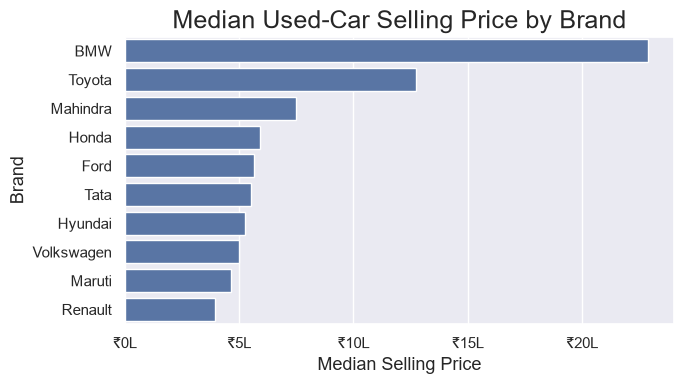

In [22]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title("Median Used-Car Selling Price by Brand", fontsize=18)
plt.xlabel("Median Selling Price", fontsize=13)
plt.ylabel("Brand", fontsize=13)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_brand.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#### 6. Fuel Type Analysis

In [23]:
fuel_counts = df["fuel_type"].value_counts()
fuel_counts

fuel_type
Petrol      7555
Diesel      7342
CNG          299
LPG           44
Electric       4
Name: count, dtype: int64

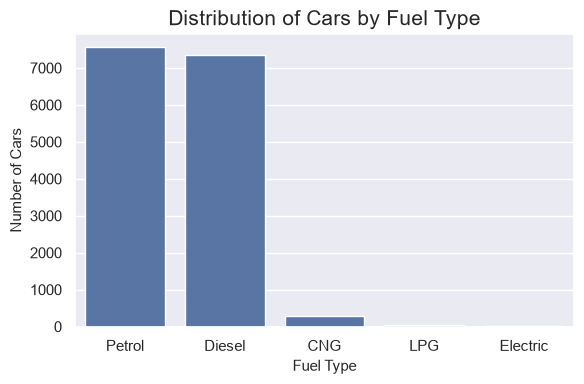

In [24]:
#visualizing the distribution of fuel types in the dataset
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="fuel_type",
    order=fuel_counts.index
)

plt.title("Distribution of Cars by Fuel Type", fontsize=15)
plt.xlabel("Fuel Type", fontsize=11)
plt.ylabel("Number of Cars", fontsize=11)

plt.tight_layout()

plt.savefig(
    "../images/car_count_by_fuel_type.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [25]:
#Does fuel type have a noticeable relationship with selling price?

fuel_price = (
    df.groupby("fuel_type")["selling_price"]
    .median()
    .sort_values(ascending=False)
)

fuel_price

fuel_type
Electric    1857500.0
Diesel       700000.0
Petrol       460000.0
CNG          370000.0
LPG          182500.0
Name: selling_price, dtype: float64

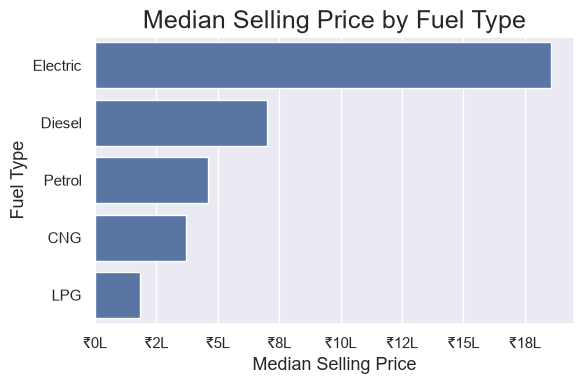

In [26]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=fuel_price.values,
    y=fuel_price.index
)

plt.title("Median Selling Price by Fuel Type", fontsize=18)
plt.xlabel("Median Selling Price", fontsize=13)
plt.ylabel("Fuel Type", fontsize=13)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_fuel_type.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#### 7. Transmission Type

In [27]:
transmission_counts = df["transmission_type"].value_counts()
transmission_counts

transmission_type
Manual       12094
Automatic     3150
Name: count, dtype: int64

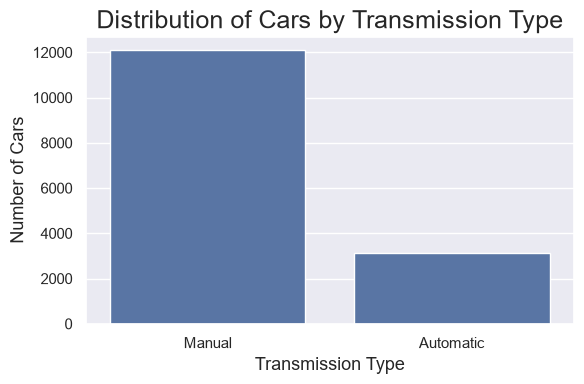

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="transmission_type",
    order=transmission_counts.index
)

plt.title("Distribution of Cars by Transmission Type", fontsize=18)
plt.xlabel("Transmission Type", fontsize=13)
plt.ylabel("Number of Cars", fontsize=13)

plt.tight_layout()

plt.savefig(
    "../images/car_count_by_transmission.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [29]:
transmission_price = (
    df.groupby("transmission_type")["selling_price"]
    .median()
    .sort_values(ascending=False)
)

transmission_price

transmission_type
Automatic    1050000.0
Manual        500000.0
Name: selling_price, dtype: float64

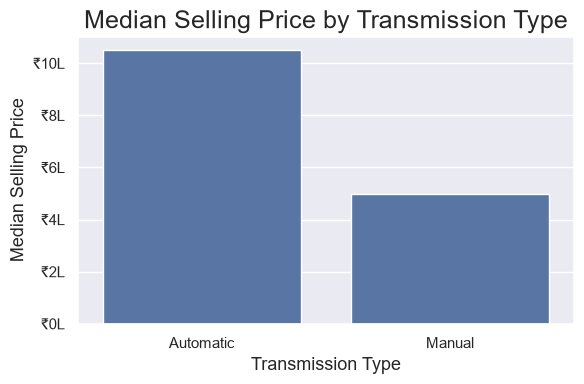

In [30]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=transmission_price.index,
    y=transmission_price.values
)

plt.title("Median Selling Price by Transmission Type", fontsize=18)
plt.xlabel("Transmission Type", fontsize=13)
plt.ylabel("Median Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_transmission.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#### 8. Engine Size vs Selling price

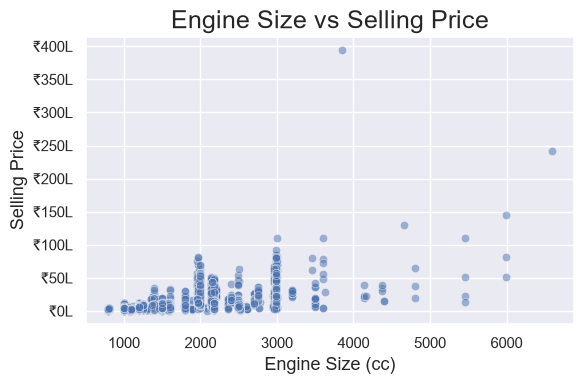

In [31]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="engine",
    y="selling_price",
    alpha=0.5
)

plt.title("Engine Size vs Selling Price", fontsize=18)
plt.xlabel("Engine Size (cc)", fontsize=13)
plt.ylabel("Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/engine_vs_price.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [32]:
df["engine"].corr(df["selling_price"])

np.float64(0.5857127836664529)

In [33]:
#means moderate positive relationship between engine size and selling price.

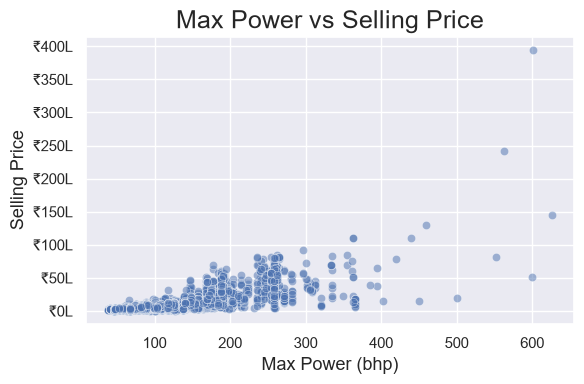

In [34]:
#max-power
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="max_power",
    y="selling_price",
    alpha=0.5
)

plt.title("Max Power vs Selling Price", fontsize=18)
plt.xlabel("Max Power (bhp)", fontsize=13)
plt.ylabel("Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/max_power_vs_price.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [35]:
df["max_power"].corr(df["selling_price"])

np.float64(0.7510584477933454)

In [36]:
#Cars with higher maximum power tend to have substantially higher selling prices.

In [37]:
df["engine"].corr(df["max_power"])

np.float64(0.8072866540888881)

In [38]:
#Multicollinearity happens when two or more input features contain very similar information.
#Here, engine and max_power have a correlation of 0.8072, so they are strongly related.

In [39]:
df["mileage"].corr(df["selling_price"])

np.float64(-0.30512849418211224)

In [40]:
#As mileage increases, selling price tends to decrease somewhat.

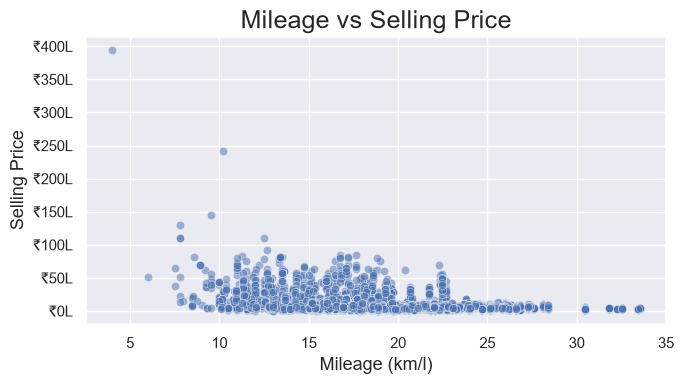

In [41]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df,
    x="mileage",
    y="selling_price",
    alpha=0.5
)

plt.title("Mileage vs Selling Price", fontsize=18)
plt.xlabel("Mileage (km/l)", fontsize=13)
plt.ylabel("Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/mileage_vs_price.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#### 8. Correlation Matrix

In [42]:
numeric_cols = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

corr_matrix = df[numeric_cols].corr()

corr_matrix

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.000000,0.332725,-0.257599,0.098734,0.004356,0.030268,-0.241228
km_driven,0.332725,1.000000,-0.104979,0.192721,0.044776,0.192026,-0.079548
mileage,-0.257599,-0.104979,1.000000,-0.632161,-0.532172,-0.439943,-0.305128
engine,0.098734,0.192721,-0.632161,1.000000,0.807287,0.551401,0.585713
max_power,0.004356,0.044776,-0.532172,0.807287,1.000000,0.172264,0.751058
seats,0.030268,0.192026,-0.439943,0.551401,0.172264,1.000000,0.115299
selling_price,-0.241228,-0.079548,-0.305128,0.585713,0.751058,0.115299,1.000000


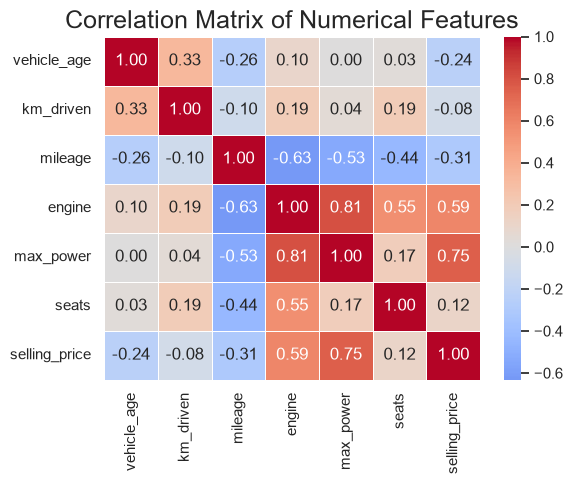

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features", fontsize=18)

plt.tight_layout()

plt.savefig(
    "../images/correlation_matrix.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

#### Categorical features evaluation

In [44]:
seller_counts = df["seller_type"].value_counts()
seller_counts

seller_type
Dealer              9459
Individual          5612
Trustmark Dealer     173
Name: count, dtype: int64

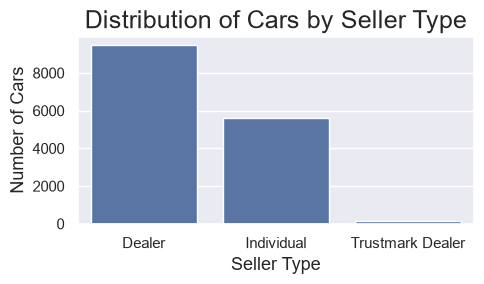

In [45]:
#Seller type distribution
plt.figure(figsize=(5,3))

sns.countplot(
    data=df,
    x="seller_type",
    order=seller_counts.index
)

plt.title("Distribution of Cars by Seller Type", fontsize=18)
plt.xlabel("Seller Type", fontsize=13)
plt.ylabel("Number of Cars", fontsize=13)

plt.tight_layout()

plt.savefig(
    "../images/car_count_by_seller_type.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [46]:
seller_price = (
    df.groupby("seller_type")["selling_price"]
    .median()
    .sort_values(ascending=False)
)

seller_price

seller_type
Dealer              590000.0
Trustmark Dealer    540000.0
Individual          510000.0
Name: selling_price, dtype: float64

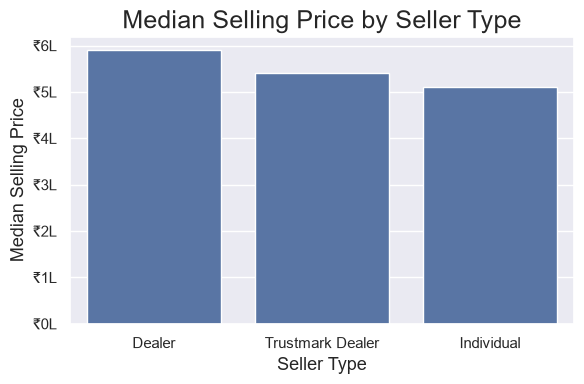

In [47]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=seller_price.index,
    y=seller_price.values
)

plt.title("Median Selling Price by Seller Type", fontsize=18)
plt.xlabel("Seller Type", fontsize=13)
plt.ylabel("Median Selling Price", fontsize=13)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(format_lakh)
)

plt.tight_layout()

plt.savefig(
    "../images/median_price_by_seller_type.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [48]:
seat_counts = df["seats"].value_counts().sort_index()

seat_counts

seats
0        2
2        7
4       76
5    12767
6      125
7     1902
8      310
9       55
Name: count, dtype: int64

In [49]:
seat_price = (
    df.groupby("seats")["selling_price"]
    .median()
    .sort_index()
)

seat_price

seats
0     634500.0
2    3425000.0
4    2750000.0
5     525000.0
6     551000.0
7     875000.0
8     795000.0
9     595000.0
Name: selling_price, dtype: float64

In [50]:
df.columns.tolist()

['car_name',
 'brand',
 'model',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price',
 'log_selling_price']

In [51]:
df["car_name"].nunique()

121

In [52]:
df["model"].nunique()

120

In [53]:
features = [
    "brand",
    "model",
    "vehicle_age",
    "km_driven",
    "seller_type",
    "fuel_type",
    "transmission_type",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

target = "selling_price"

In [54]:
#remember
#log_selling_price → keep for later experiment, NOT an input feature
#car_name          → drop from model

In [55]:
X = df[features]
y = df["selling_price"]

X.shape, y.shape

((15244, 11), (15244,))

## Model 

In [56]:
#We have 6 categorical features that are text-based:
# brand
# model
# seller_type
# fuel_type
# transmission_type

#### Train/Test Split

In [57]:
#80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12195, 11), (3049, 11), (12195,), (3049,))

In [58]:
#Training set → 12,195 cars
#Testing set  → 3,049 cars

### One-Hot Encoding

In [59]:
categorical_cols = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

numeric_cols = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",    #helps to reduce crashes when the test set has a category that the training set does not have
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

In [61]:
#Why two different Operations?

# Training data → fit_transform()
# Testing data  → transform()

# fit_transform() means:
# Learn the categories from the training data and convert them into 0/1 columns.

# transform() means:
# Use those already-learned categories to convert the test data.

In [62]:
X_train_cat.shape, X_test_cat.shape

((12195, 161), (3049, 161))

In [63]:
#Now, Combine numerical + encoded categorical features
X_train_final = np.hstack([
    X_train[numeric_cols].values,
    X_train_cat
])

X_test_final = np.hstack([
    X_test[numeric_cols].values,
    X_test_cat
])

In [64]:
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (12195, 167)
X_test_final: (3049, 167)


### Training first Linear Regression Model

In [65]:
#importing Linear Regression
from sklearn.linear_model import LinearRegression

In [66]:
#create the model
model = LinearRegression()

In [67]:
#Training it
model.fit(X_train_final, y_train)

# X_train_final - our 167 input features
# y_train - actual car selling prices
# .fit() - the model learns the relationship between the features and price

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](167,)","[ -76959.24, -1.07, -8976.87,...,-153505.03, 3634.26, -3634.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.702e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,167
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(82)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](167,)","[4666806.81, 56033.85, 2722.79,..., 0. , 0. , 0. ]"


In [68]:
#making prediction
y_pred = model.predict(X_test_final)

#Now y_pred contains the prices predicted by our model for the 3,049 test cars.

In [69]:
print(y_pred[:10])

[ 576725.98316216  507775.15469921  707538.03116322 3709737.83852695
  884506.69369523  643585.65046369  348628.78048197 1551025.53764516
  773999.04669472  722433.55487258]


#### Evaluate the Linear Regression model

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [71]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

In [72]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 209456.17594737012
RMSE: 397125.9813709751
R²  : 0.7406190067700582


#### Can Linear Regression predict car prices better when we train it on log_selling_price instead of the original selling_price?

In [73]:
#Now, create the log target
y_log = df["log_selling_price"]

In [74]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

In [75]:
#creating model
log_model = LinearRegression()

log_model.fit(
    X_train_final,
    y_train_log
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](167,)","[-0.11,-0. ,-0.01,...,-0.08, 0.06,-0.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,167
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(82)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](167,)","[4666806.81, 56033.85, 2722.79,..., 0. , 0. , 0. ]"


In [76]:
log_pred = log_model.predict(X_test_final)

In [77]:
#Note: log_pred is not in rupees. It's in log-price units.

In [78]:
log_pred_price = np.expm1(log_pred)

In [79]:
print(log_pred_price[:10])

[ 574528.2186244   409127.78978137  665291.24186398 3799198.09829202
  668713.58112392  548293.8013082   212773.86764357 1032963.20064932
  643348.99414227  685347.23874089]


In [80]:
#Now, evaluate the log target model
mae_log = mean_absolute_error(y_test, log_pred_price)
rmse_log = np.sqrt(mean_squared_error(y_test, log_pred_price))
r2_log = r2_score(y_test, log_pred_price)

In [81]:
print("Log Model MAE :", mae_log)
print("Log Model RMSE:", rmse_log)
print("Log Model R²  :", r2_log)

Log Model MAE : 133385.51746976853
Log Model RMSE: 406532.6207761909
Log Model R²  : 0.7281856716205568


In [82]:
import joblib

model_artifact = {
    "model": log_model,
    "encoder": encoder
}

joblib.dump(
    model_artifact,
    "../models/car_price_model.pkl"
)

['../models/car_price_model.pkl']

#### Model 3 — Remove highly correlated features

In [83]:
numeric_cols = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

numeric_cols_reduced = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "max_power",
    "seats"
]

In [84]:
X_train_reduced = np.hstack([
    X_train[numeric_cols_reduced].values,
    X_train_cat
])

X_test_reduced = np.hstack([
    X_test[numeric_cols_reduced].values,
    X_test_cat
])

In [85]:
print("X_train_reduced:", X_train_reduced.shape)
print("X_test_reduced:", X_test_reduced.shape)

X_train_reduced: (12195, 166)
X_test_reduced: (3049, 166)


In [86]:
#Model 3 training
model_3 = LinearRegression()

model_3.fit(
    X_train_reduced,
    y_train_log
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](166,)","[-0.11,-0. ,-0.01,...,-0.1 , 0.06,-0.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.37
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,166
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(81)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](166,)","[4666787.09, 4780.49, 405.9 ,..., 0. , 0. , 0. ]"


In [87]:
y_pred_3_log = model_3.predict(X_test_reduced)

In [88]:
y_pred_3 = np.expm1(y_pred_3_log)

In [89]:
X_train_reduced.shape

(12195, 166)

In [90]:
X_test_reduced.shape

(3049, 166)

In [91]:
print("X_train_reduced:", X_train_reduced.shape)
print("X_test_reduced:", X_test_reduced.shape)

X_train_reduced: (12195, 166)
X_test_reduced: (3049, 166)


In [92]:
#testing the model 3
mae_3 = mean_absolute_error(y_test, y_pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))
r2_3 = r2_score(y_test, y_pred_3)

print("Model 3 MAE :", mae_3)
print("Model 3 RMSE:", rmse_3)
print("Model 3 R²  :", r2_3)

Model 3 MAE : 134317.21629292044
Model 3 RMSE: 407328.53727137996
Model 3 R²  : 0.727120304291764


#### Model 2's predictions, log_pred_price

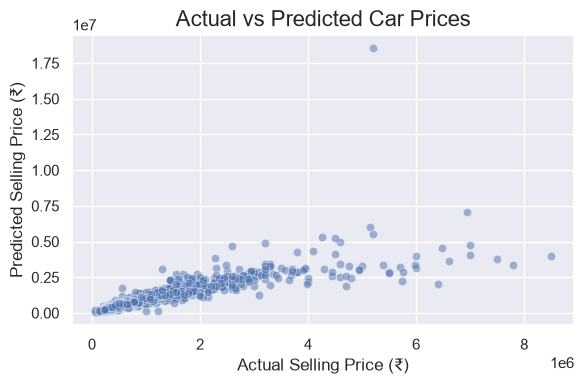

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.scatterplot(
    x=y_test,
    y=log_pred_price,
    alpha=0.5
)

plt.xlabel("Actual Selling Price (₹)")
plt.ylabel("Predicted Selling Price (₹)")
plt.title("Actual vs Predicted Car Prices", fontsize=16)

plt.tight_layout()
plt.savefig(
    "../images/actual_vs_predicted_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Log-scale diagnostic plot

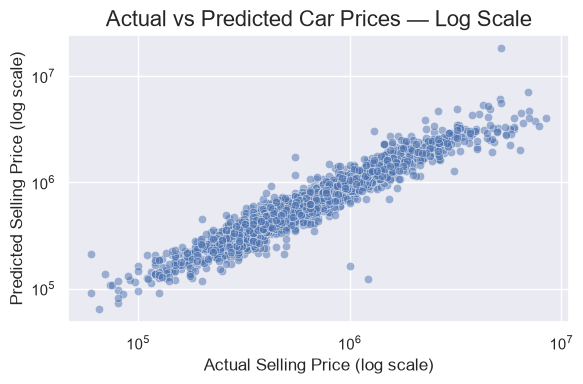

In [94]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=y_test,
    y=log_pred_price,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Selling Price (log scale)")
plt.ylabel("Predicted Selling Price (log scale)")
plt.title("Actual vs Predicted Car Prices — Log Scale", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../images/actual_vs_predicted_price_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
residuals = y_test - log_pred_price

In [96]:
print(residuals.head(10))

4093     1.054718e+05
10766   -5.912779e+04
10375    9.708758e+03
3774     3.700802e+06
8779    -2.197136e+05
7959     7.170620e+04
6739     7.622613e+04
3214    -1.329632e+05
2417    -1.333490e+05
5219    -1.353472e+05
Name: selling_price, dtype: float64
